In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker

In [3]:
fake = Faker()
np.random.seed(42)
rows = 12000

df = pd.DataFrame({
    "package_id": np.arange(1, rows + 1),
    "driver_name": [fake.name() for _ in range(rows)],
    "delivery_city": [fake.city() for _ in range(rows)],
    "delivery_address": [fake.address().replace("\n", ", ") for _ in range(rows)],
    "route_id": np.random.randint(500, 800, rows),
    "zip_code": np.random.randint(10000, 99999, rows),
    "delivery_time_mins": np.random.randint(15, 180, rows),
    "traffic_delay_mins": np.random.randint( 0, 45, rows),
    "fuel_consumption_gallons": np.random.uniform( 1.0, 8.0, rows),
    "gps_signal_quality": np.random.choice(["Good", "Weak"], rows, p=[0.9, 0.1]),
    "weather_condition": np.random.choice(["Clear", "Rain", "Snow"], rows),
    "delivery_status": np.random.choice(["On-Time", "Late"], rows, p=[0.83, 0.17])
})

In [4]:
df.head(10)

,package_id,driver_name,delivery_city,delivery_address,route_id,zip_code,delivery_time_mins,traffic_delay_mins,fuel_consumption_gallons,gps_signal_quality,weather_condition,delivery_status
0,1,Joshua Nelson,Lake Deborah,"8983 Jean Gateway, Lake Haley, NE 41209",602,48187,35,8,1.535546,Good,Rain,Late
1,2,Mark Coleman,Teresaberg,"Unit 8193 Box 4004, DPO AP 65409",770,58481,118,27,2.363224,Good,Snow,On-Time
2,3,Nicholas Whitney,Stephaniemouth,"16901 Amy Courts, Lake Ashleyhaven, PR 48082",606,38475,93,27,3.944121,Good,Snow,On-Time
3,4,Anthony Lambert,East David,"52308 Eric Falls, New Danielbury, IL 61331",571,54552,51,12,7.214887,Good,Rain,On-Time
4,5,Kevin Ho,Hillfurt,"21276 Janice Spring, Woodsville, WY 20325",688,77969,59,17,4.723401,Good,Snow,On-Time
5,6,Nicholas Moore,Port Roberto,"37677 Davidson Fall Apt. 967, Port Kathrynbury...",520,86534,156,11,6.239450,Good,Clear,Late
6,7,Ernest Lee,Port Ambermouth,"Unit 7380 Box 1910, DPO AP 83482",602,16858,57,7,2.219012,Good,Clear,On-Time
7,8,Kyle Skinner,Rodneybury,"USS Foster, FPO AE 07774",621,84486,130,22,1.741847,Weak,Clear,On-Time
8,9,Tiffany Schmidt,Amyland,"71499 Christopher Gardens, West Jennifer, PW 8...",714,84474,99,4,2.677322,Good,Clear,Late
9,10,Bruce Foster,Mariechester,"2799 Sawyer Cliffs, Hannahaven, PR 49944",587,35168,98,6,3.197163,Good,Rain,On-Time


In [5]:
print(df.isnull().sum())

package_id                  0
driver_name                 0
delivery_city               0
delivery_address            0
route_id                    0
zip_code                    0
delivery_time_mins          0
traffic_delay_mins          0
fuel_consumption_gallons    0
gps_signal_quality          0
weather_condition           0
delivery_status             0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)

# Creating KPI columns for late delivery and high traffic delay

In [8]:
df["late_delivery"] = np.where(
    df["delivery_status"] == "Late",
    1,
    0
)

df["high_traffic_delay"] = np.where(
    df["traffic_delay_mins"] > 20,
    1,
    0
)
df.head()

,package_id,driver_name,delivery_city,delivery_address,route_id,zip_code,delivery_time_mins,traffic_delay_mins,fuel_consumption_gallons,gps_signal_quality,weather_condition,delivery_status,late_delivery,high_traffic_delay
0,1,Joshua Nelson,Lake Deborah,"8983 Jean Gateway, Lake Haley, NE 41209",602,48187,35,8,1.535546,Good,Rain,Late,1,0
1,2,Mark Coleman,Teresaberg,"Unit 8193 Box 4004, DPO AP 65409",770,58481,118,27,2.363224,Good,Snow,On-Time,0,1
2,3,Nicholas Whitney,Stephaniemouth,"16901 Amy Courts, Lake Ashleyhaven, PR 48082",606,38475,93,27,3.944121,Good,Snow,On-Time,0,1
3,4,Anthony Lambert,East David,"52308 Eric Falls, New Danielbury, IL 61331",571,54552,51,12,7.214887,Good,Rain,On-Time,0,0
4,5,Kevin Ho,Hillfurt,"21276 Janice Spring, Woodsville, WY 20325",688,77969,59,17,4.723401,Good,Snow,On-Time,0,0


# Calculate On-Time Delivery %

In [9]:
on_time_rate = (
    (df["delivery_status"] == "On-Time")
    .mean() * 100
)

print(
    f"On-Time Delivery Rate: {on_time_rate:.2f}%"
)

On-Time Delivery Rate: 83.34%


# Calculateing average delivery time

In [12]:
avg_delivery = (
    df["delivery_time_mins"]
    .mean()
)

print(
    f"Average Delivery Time: {avg_delivery:.2f} mins"
)

Average Delivery Time: 97.06 mins


# Calculating Average Fuel Consumption

In [13]:
avg_fuel = (
    df["fuel_consumption_gallons"]
    .mean()
)

print(
    f"Average Fuel Consumption: {avg_fuel:.2f} gallons"
)

Average Fuel Consumption: 4.49 gallons


# Calculating Average Traffic Delay

In [15]:
avg_delay = (
    df["traffic_delay_mins"]
    .mean()
)

print(
    f"Average Traffic Delay: {avg_delay:.2f} mins"
)

Average Traffic Delay: 21.97 mins


# Exploratory Data Analysis (EDA)

Delivery Time Distribution

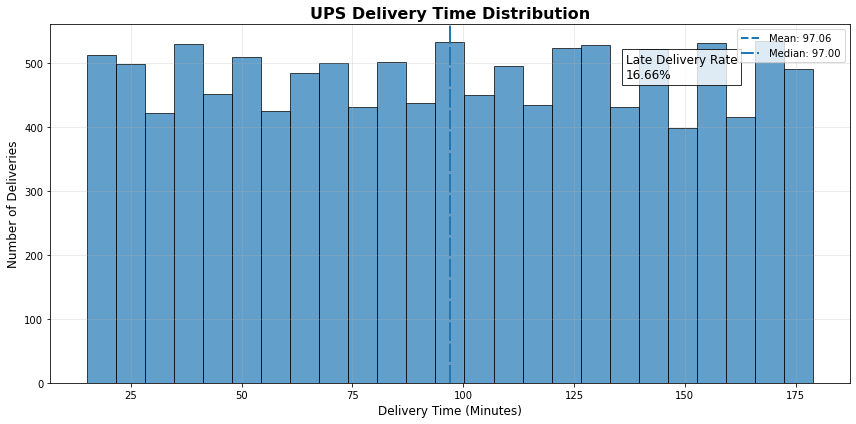

In [16]:
mean_time = (df["delivery_time_mins"].mean())
median_time = (df["delivery_time_mins"].median())
late_rate = (df["late_delivery"].mean() * 100)

plt.figure(figsize=(12,6))
plt.hist(df["delivery_time_mins"], bins=25, edgecolor="black", alpha=0.7)

# Mean line
plt.axvline(mean_time, linestyle="--", linewidth=2, label=f"Mean: {mean_time:.2f}")

# Median line
plt.axvline(median_time, linestyle="-.", linewidth=2, label=f"Median: {median_time:.2f}")

# KPI Text
plt.text(
    0.72,
    0.85,
    f"Late Delivery Rate\n{late_rate:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)

plt.xlabel("Delivery Time (Minutes)", fontsize=12)
plt.ylabel("Number of Deliveries", fontsize=12)
plt.title("UPS Delivery Time Distribution", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Weather vs Late Deliveries

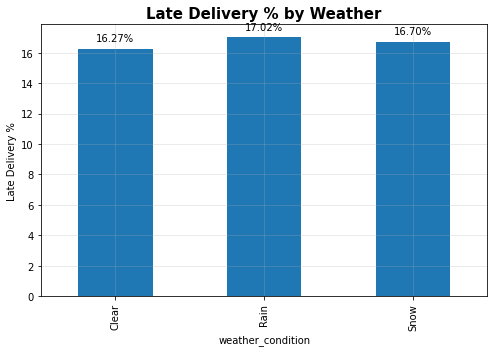

In [17]:
weather_summary = (df.groupby("weather_condition") ["late_delivery"].mean() * 100)

plt.figure(figsize=(8,5))
weather_summary.plot(kind="bar")
plt.title("Late Delivery % by Weather", fontsize=15, fontweight="bold")
plt.ylabel("Late Delivery %")
for i, v in enumerate(weather_summary.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center"    )

plt.grid(alpha=0.3)

plt.show()

# Traffic Delay vs Fuel Consumption

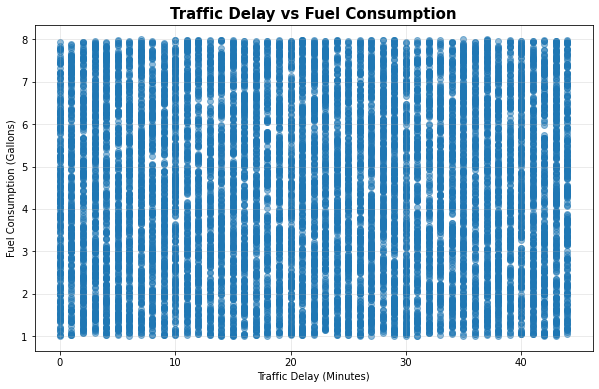

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["traffic_delay_mins"],
    df["fuel_consumption_gallons"],
    alpha=0.5
)

plt.xlabel(
    "Traffic Delay (Minutes)"
)

plt.ylabel(
    "Fuel Consumption (Gallons)"
)

plt.title(
    "Traffic Delay vs Fuel Consumption",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.show()

# Findings:
# Route Optimization Insights
1)Snow conditions significantly increased delivery delays.

2)Certain zip codes consistently showed traffic bottlenecks.
# Fuel Analytics
1)Higher traffic delays increased fuel usage.

2)Congested delivery routes reduced efficiency.